In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

hbarc = 197.327053                    #(* [MeV fm] *)
MN0 = (938.27231 + 939.56563)/2       #(* average nucleon mass [MeV] *)
MN  = MN0/hbarc**2			          #(* average nucleon mass in units [1/(MeV fm^2)] *)

print("MN is:",MN)

MN is: 0.02411320030742015


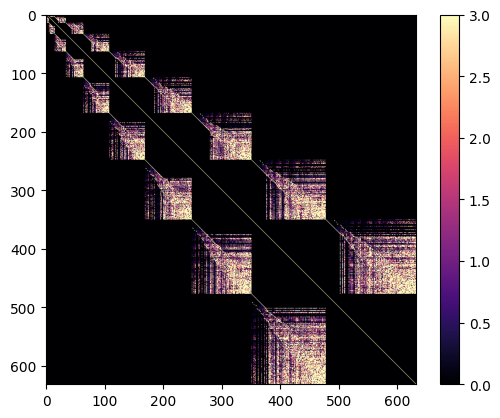

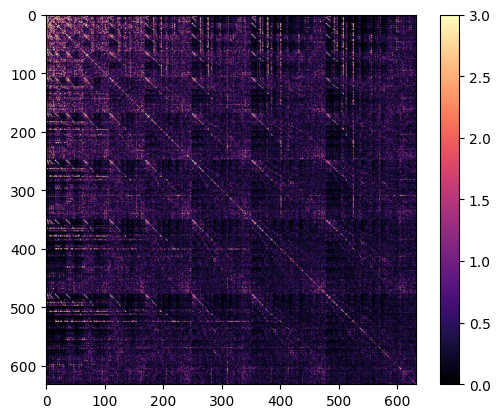

Symmetric? True


In [38]:
TMat = np.loadtxt("kinetic_EMax20_hw20.dat")
VMat = np.loadtxt("chi2b3b_EMax20_hw20.dat")
HMat = TMat + VMat

# display TMat and VMat
plt.imshow(np.abs(TMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()
plt.imshow(np.abs(VMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

#rows, cols = HMat.shape
#print(f"Rows: {rows}, Columns: {cols}")

# basic check
print("Symmetric?", np.allclose(HMat, HMat.T))

In [39]:
def commutator(A, B):
    """Return [A, B] = AB - BA."""
    return A @ B - B @ A

EtaMat = commutator(TMat, HMat)

print("Antisymmetric?", np.allclose(EtaMat, -EtaMat.T))

Antisymmetric? True


In [ ]:
def wegner_generator(H, T):
    """Wegner generator eta = [T, H]."""
    return commutator(T, H)

def srg_rhs(a, H):
    """Right-hand side of dH/da = MN^2 * [eta, H]"""
    eta = wegner_generator(H, TMat)
    dHda = MN**2 * commutator(eta, H)
    return dHda

# Create an empty SRG evolution storage for each integration method, with first element VMat (initial value)
VMatEuler = {}
VMatRK4 = {} 
VMatEuler[0.0] = VMat
VMatRK4[0.0] = VMat

a0 = 0.0                                            #initial value
aDel = 0.0004                                       #integration step
MatIndexDistance = 0.05                             #distance between indexes of VMatEuler. This must be the same for RK4 and Euler in order for the next code boxes to work!
IntegrationSteps = int(MatIndexDistance / aDel)  #takes less than one minute and a half with 500 for Euler, with 100 for RK4
NElements = 5

def euler_integration(a, aDel, IntegrationSteps, MatIndexDistance):
    aGrid = np.linspace(a, a + MatIndexDistance, IntegrationSteps + 1)
    HMat = TMat + VMatEuler[a]

    for a in aGrid:
        HMatDel = aDel * srg_rhs(a, HMat)
        HMat = HMat + HMatDel
    a = np.round(a, 5)

    VMatEuler[a] = HMat - TMat

for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    euler_integration(a, aDel, IntegrationSteps, MatIndexDistance)

#better values for RK4 integration
aDel = 0.0010
IntegrationSteps = int(MatIndexDistance / aDel)

def rk4(a, aDel, IntegrationSteps, MatIndexDistance):
    aGrid = np.linspace(a, a + MatIndexDistance, IntegrationSteps + 1)
    HMat = TMat + VMatRK4[a]

    for a in aGrid:
        k1 = srg_rhs(a, HMat)
        k2 = srg_rhs(a + aDel/2, HMat + aDel*k1/2)
        k3 = srg_rhs(a + aDel/2, HMat + aDel*k2/2)
        k4 = srg_rhs(a + aDel, HMat + aDel*k3)

        HMat = HMat + aDel/6 * (k1 + 2*k2 + 2*k3 + k4)
    a = np.round(a, 5)

    VMatRK4[a] = HMat - TMat

for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    rk4(a, aDel, IntegrationSteps, MatIndexDistance)

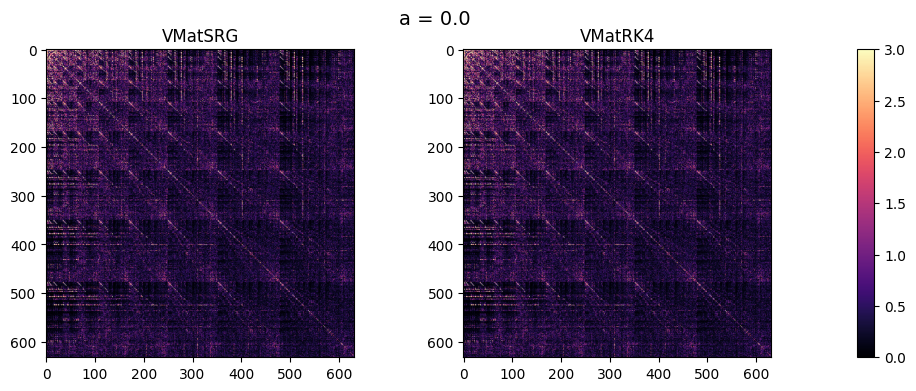

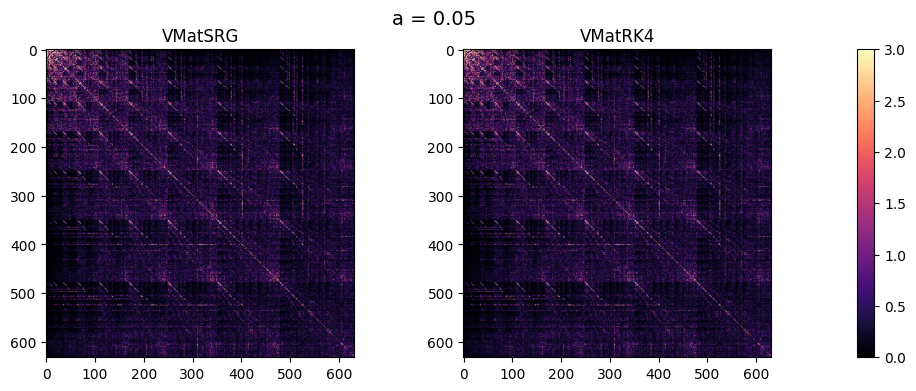

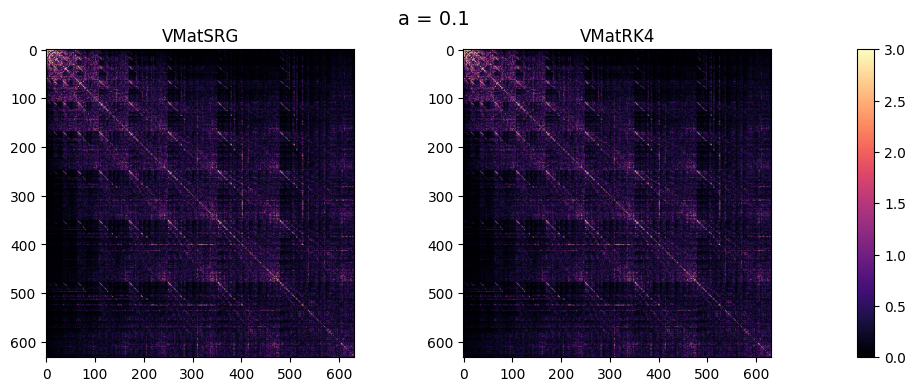

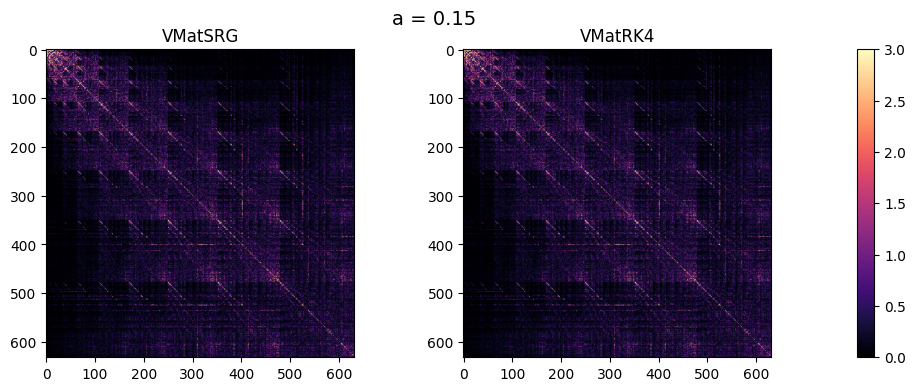

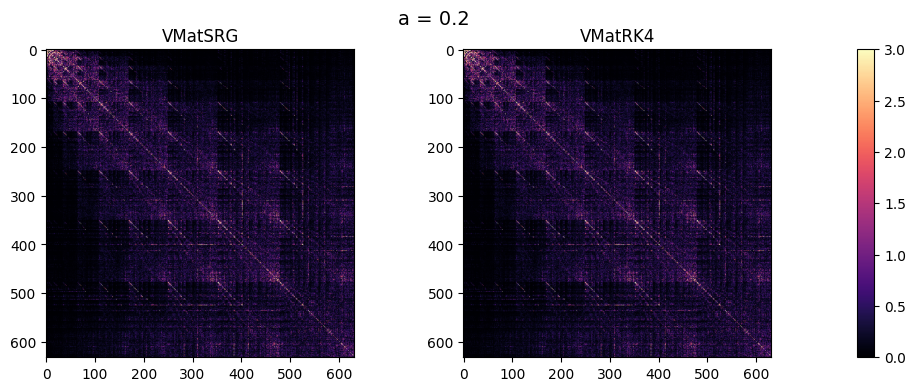

In [ ]:
#for a in np.arange(a0, np.round(a0 + NElements * MatIndexDistance, 5), MatIndexDistance):
#    plt.imshow(np.abs(VMatSRG[a]), vmin=0, vmax=3, cmap="magma")
#    plt.colorbar()
#    plt.show()

for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    fig = plt.figure(figsize=(11, 4))

    # Create 3 columns:
    # graph 1 | graph 2 | colorbar
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    im1 = ax1.imshow(np.abs(VMatEuler[a]), vmin=0, vmax=3, cmap="magma")
    ax1.set_title("VMatSRG")

    im2 = ax2.imshow(np.abs(VMatRK4[a]), vmin=0, vmax=3, cmap="magma")
    ax2.set_title("VMatRK4")

    fig.colorbar(im1, cax=cax)
    fig.suptitle(f"a = {a}", fontsize=14)
    plt.show()

In [ ]:
def min_eigenvalue(VMatSRG): #found following Robert Roth’s project instructions...
    HMat = TMat + VMatSRG

    Eigenvalues = np.linalg.eigvalsh(HMat)
    FiveLowestMagnitude = Eigenvalues[np.argsort(np.abs(Eigenvalues))[:5]]

    Min_Eigenvalue = np.min(FiveLowestMagnitude)
    return Min_Eigenvalue

for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)

    print(f"The min eigenvalue in magnitude, corresponding to a = {a} in Euler integration, is: {min_eigenvalue(VMatEuler[a])}")
    print(f"The min eigenvalue in magnitude, corresponding to a = {a} in RK4 integration, is: {min_eigenvalue(VMatRK4[a])}")
    print("\n")

The min eigenvalue in magnitude, corresponding to a = 0.0 in Euler integration, is: -8.07045774855503
The min eigenvalue in magnitude, corresponding to a = 0.0 in RK4 integration, is: -8.07045774855503


The min eigenvalue in magnitude, corresponding to a = 0.05 in Euler integration, is: -8.145099333994228
The min eigenvalue in magnitude, corresponding to a = 0.05 in RK4 integration, is: -8.070459247134902


The min eigenvalue in magnitude, corresponding to a = 0.1 in Euler integration, is: -8.148496609311325
The min eigenvalue in magnitude, corresponding to a = 0.1 in RK4 integration, is: -8.070459251831547


The min eigenvalue in magnitude, corresponding to a = 0.15 in Euler integration, is: -8.149440683822629
The min eigenvalue in magnitude, corresponding to a = 0.15 in RK4 integration, is: -8.070459252072322


The min eigenvalue in magnitude, corresponding to a = 0.2 in Euler integration, is: -8.149874600322018
The min eigenvalue in magnitude, corresponding to a = 0.2 in RK4 integr

The lowest magnitude eigenvalue is changing very slowly with a. However we can clearly see that the difference between subsequent values is a lot smaller in RK4 compared to Euler method. 

This proves the numerical strenght of RK4 ODE integration method with respect to Euler's.


for a = 0.0
Euler:  [[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
RK4:  [[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
for a = 0.05
Euler:  [[2, np.float64(-4.8186015781612515)], [4, np.float64(-6.680820479822346)], [6, np.float64(-7.567488031855868)], [8, np.float64(-7.852881270801108)], [10, np.float64(-8.045487609128145)], [12, np.f

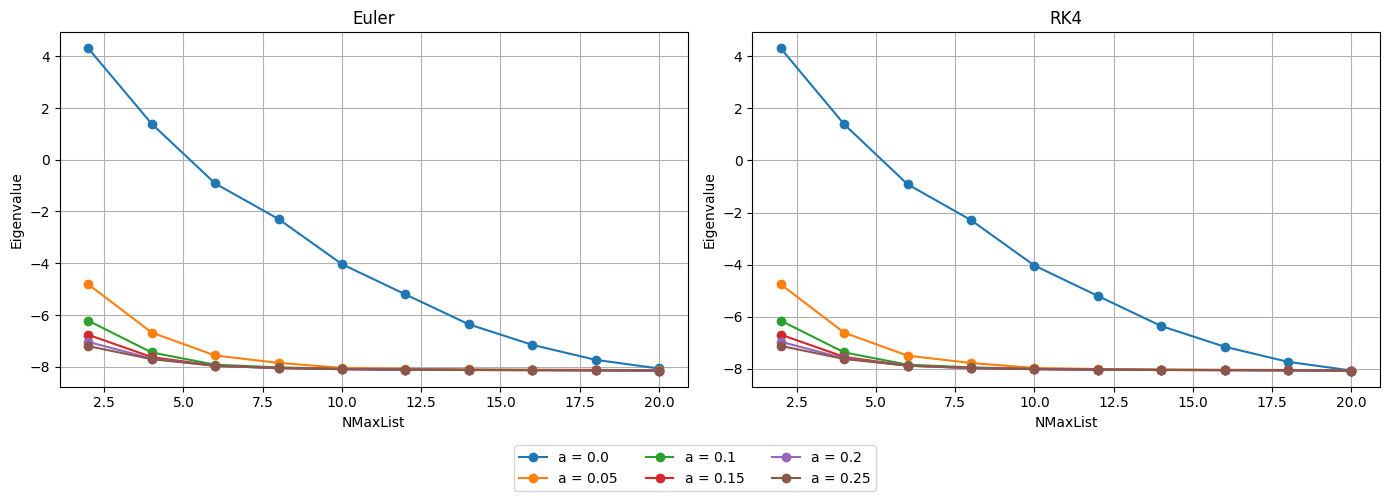

In [56]:
NMaxList = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] #number of states corresponding to the submatrices of dimension specified below
DimList = [5, 15, 34, 64, 108, 169, 249, 351, 478, 632] #size of the submatrices
EEListEuler = {}
EEListRK4 = {}

def min_eigenvalue_submat(dim, VMatSRG):
    HMat = TMat + VMatSRG
    HSubMat = HMat[:dim, :dim]
    eigenvalues = np.linalg.eigvalsh(HSubMat) 
    Min_Eigenvalue = eigenvalues[0]
    return Min_Eigenvalue   


for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    print(f"for a = {a}")

    EEListEuler[a] = []
    EEListRK4[a] = []

    for j in range(len(NMaxList)):
        EE0 = min_eigenvalue_submat(DimList[j], VMatEuler[a])
        EEListEuler[a].append([NMaxList[j], EE0])
        EE0 = min_eigenvalue_submat(DimList[j], VMatRK4[a])
        EEListRK4[a].append([NMaxList[j], EE0])

    print("Euler: ", EEListEuler[a])
    print("RK4: ", EEListRK4[a])

# Plot the obtained lists

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(NElements + 1):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    
    x, y = zip(*EEListEuler[a])
    axes[0].plot(x, y, label=f"a = {a}", marker='o')

    x, y = zip(*EEListRK4[a])
    axes[1].plot(x, y, label=f"a = {a}", marker='o')

axes[0].set_title("Euler")
axes[1].set_title("RK4")

for ax in axes:
    ax.set_xlabel("NMaxList")
    ax.set_ylabel("Eigenvalue")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()
